# Restaurant Revenue Prediction
## 1. EDA
**Regression** project on the kaggle restaurant dataset. 
**Goal:** predict the annual revenue of a restaurant from its opening date, city, city group, type, and 37 anonymised numeric features P1-P37 (obfuscated for privacy).

Dataset is small, and hard - **only 137 rows** - so EDA is about finding which few signals actually relate to revenue and setting realistic expectation for modelling

### Importing libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import utils
%matplotlib inline

df= utils.load_data()
print('shape:', df.shape)
df.head()

shape: (137, 43)


,Id,Open Date,City,City Group,Type,P1,P2,P3,P4,P5,...,P29,P30,P31,P32,P33,P34,P35,P36,P37,revenue
0,0,07/17/1999,İstanbul,Big Cities,IL,4,5.0,4.0,4.0,2,...,3.0,5,3,4,5,5,4,3,4,5653753.0
1,1,02/14/2008,Ankara,Big Cities,FC,4,5.0,4.0,4.0,1,...,3.0,0,0,0,0,0,0,0,0,6923131.0
2,2,03/09/2013,Diyarbakır,Other,IL,2,4.0,2.0,5.0,2,...,3.0,0,0,0,0,0,0,0,0,2055379.0
3,3,02/02/2012,Tokat,Other,IL,6,4.5,6.0,6.0,4,...,7.5,25,12,10,6,18,12,12,6,2675511.0
4,4,05/09/2009,Gaziantep,Other,IL,3,4.0,3.0,4.0,2,...,3.0,5,1,3,2,3,4,3,3,4316715.0


### a) Target: Revenue Distribution

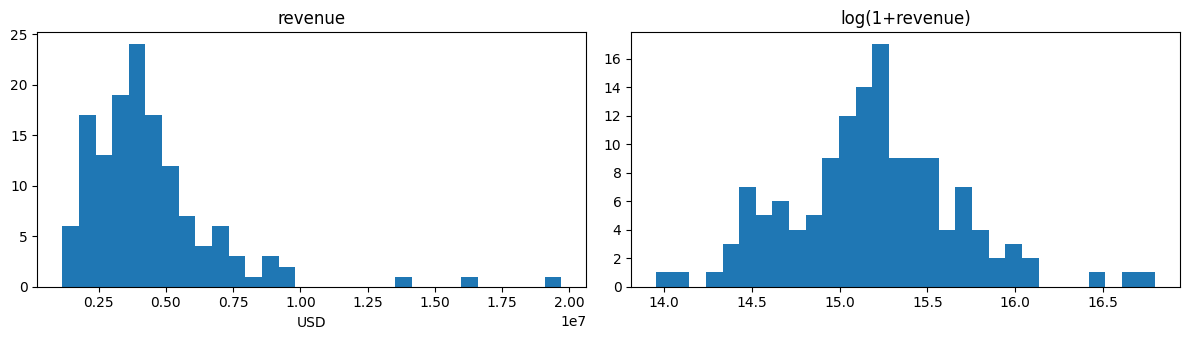

count         137.0
mean      4453533.0
std       2576072.0
min       1149870.0
25%       2999068.0
50%       3939804.0
75%       5166635.0
max      19696939.0


In [4]:
fig, ax= plt.subplots(1,2,figsize= (12, 3.5))
ax[0].hist(df['revenue'], bins = 30); ax[0].set_title('revenue'); ax[0].set_xlabel('USD')
ax[1].hist(np.log1p(df['revenue']), bins=30); ax[1].set_title('log(1+revenue)')
plt.tight_layout(); plt.show()
print(df['revenue'].describe().round(0).to_string())

We can see from the histogram that the data is right-skewed with a long tail, which will hurt linear models unless regularised.

### b) Revenue by City Group and Type

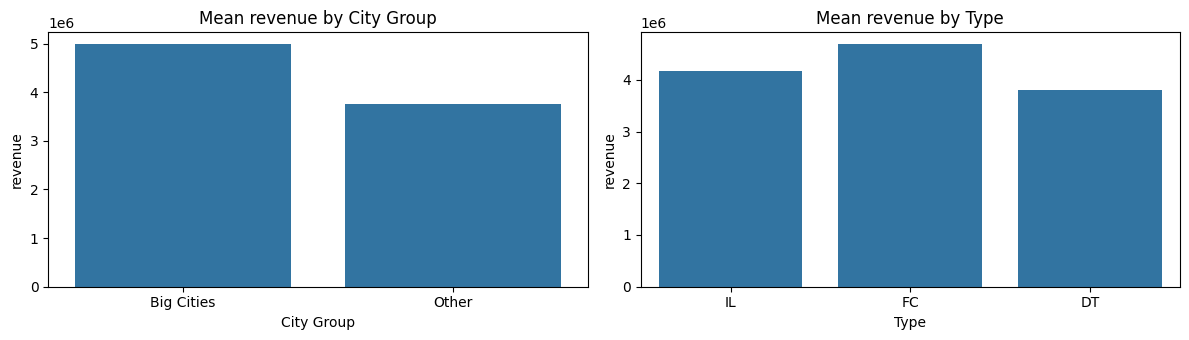

                 mean  count
City Group                  
Big Cities  4983480.0     78
Other       3752924.0     59

           mean  count
Type                  
DT    3810007.0      1
FC    4683963.0     76
IL    4172379.0     60


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
sns.barplot(x='City Group', y='revenue', data=df, ax=ax[0], estimator=np.mean, errorbar=None)
ax[0].set_title('Mean revenue by City Group')
sns.barplot(x='Type', y='revenue', data=df, ax=ax[1], estimator=np.mean, errorbar=None)
ax[1].set_title('Mean revenue by Type')
plt.tight_layout(); plt.show()
print(df.groupby('City Group')['revenue'].agg(['mean','count']).round(0).to_string())
print()
print(df.groupby('Type')['revenue'].agg(['mean','count']).round(0).to_string())

We can see that, as one would estimate, big cities have more revenue than other small towns.

### c) Restaurant Age (from Open Date)

**Open Date** itself is not a model feature, but the **age** is because older tend to be more established earners.

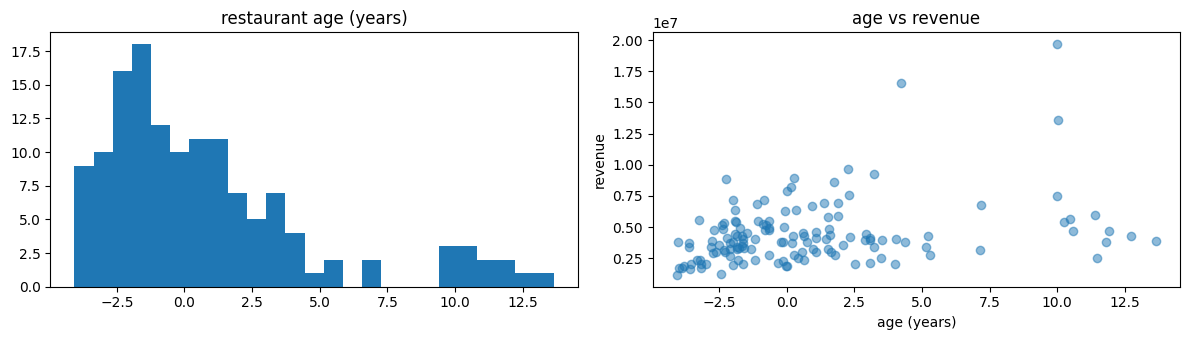

age stats:
count    137.00
mean       0.78
std        4.03
min       -4.07
25%       -1.97
50%       -0.15
75%        2.09
max       13.65

 age-revenue correlation:  0.3258


In [6]:
fe= utils.create_features(df)
fig, ax= plt.subplots(1,2, figsize= (12, 3.5))
ax[0].hist(fe['restaurant_age_years'], bins = 25); ax[0].set_title('restaurant age (years)')
ax[1].scatter(fe['restaurant_age_years'], fe['revenue'], alpha=0.5)
ax[1].set_xlabel('age (years)'); ax[1].set_ylabel('revenue'); ax[1].set_title('age vs revenue')
plt.tight_layout(); plt.show()
print('age stats:'); print(fe['restaurant_age_years'].describe().round(2).to_string())
print('\n age-revenue correlation: ', round(fe['restaurant_age_years'].corr(fe['revenue']), 4))

 age-revenue correlation:  0.3258 suggest weak to moderate correlation between the age of the restaurant and its revenue

### d) P1-P37 obfuscated features

zero-fraction (max across p-cols): 0.65

Top 6 P-features by [correlation] with revenue:
P2     0.192
P28    0.156
P6     0.139
P29    0.115
P13    0.105
P21    0.097


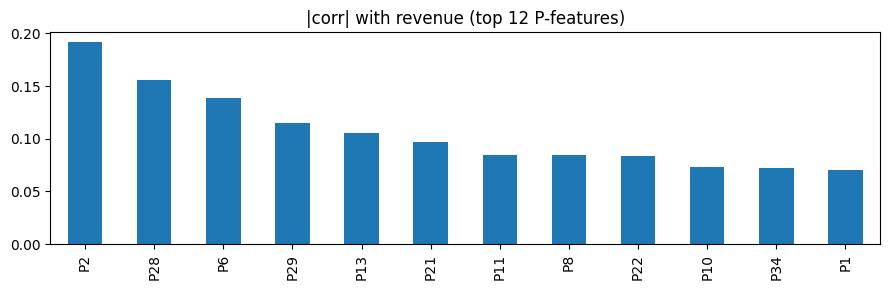

In [8]:
p_cols= [c for c in df.columns if c.startswith('P')]
pcorr= df[p_cols].corrwith(df['revenue']).abs().sort_values(ascending=False)
print('zero-fraction (max across p-cols):', round((df[p_cols]==0).mean().max(), 2))
print('\nTop 6 P-features by [correlation] with revenue:')
print(pcorr.head(6).round(3).to_string())
fig, ax= plt.subplots(figsize=(9,3))
pcorr.head(12).plot(kind= 'bar', ax=ax); ax.set_title('|corr| with revenue (top 12 P-features)')
plt.tight_layout(); plt.show()

top 6 p-features are P- 2, 28, 6, 29, 13, 21 with 2 having the highest correlation of 0.192 (weak corr) to 21 having the least 0.097 (very very weak)

### e) Correlation Heatmap

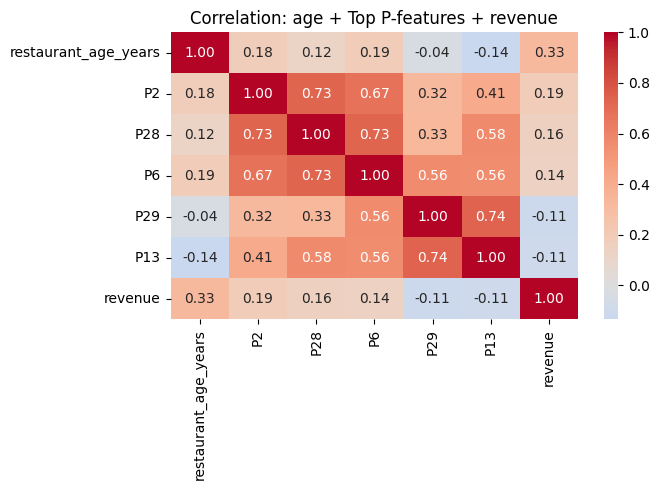

In [9]:
top_p= pcorr.head(5).index.tolist()
sub = fe[['restaurant_age_years'] + top_p + ['revenue']]
fig, ax= plt.subplots(figsize=(7, 5))
sns.heatmap(sub.corr(), annot=True, fmt='.2f', cmap= 'coolwarm', center=0, ax=ax)
ax.set_title('Correlation: age + Top P-features + revenue'); plt.tight_layout(); plt.show()

### f) Summary of findings


- **137 rows, 0 missing values, 43 columns.** This is a very small dataset for 40+ candidate features — overfitting is the central risk.

- **revenue is right-skewed** (mean ≈ \\$4.45M, max ≈ \\$19.7M). 

- **City Group matters:** Big-City restaurants average ≈ 3.75M for Other. **Type** is less clear and `DT` has only 1 row.

- **Restaurant age is the single strongest signal** (corr ≈ **0.33** with revenue) — older restaurants can earn more.

- **The P-features are individually weak** (top |corr| = P2 at 0.19) and many are zero-filled. Predictive power, if any, is diffuse.

- Expect **modest model performance**; notebooks 02–03 engineer features and quantify exactly how predictable revenue is.